# 재고 지표 산출


https://www.statsmodels.org/stable/regression.html

https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.from_formula.html#statsmodels.regression.linear_model.OLS.from_formula

https://www.statsmodels.org/stable/examples/notebooks/generated/ols.html

https://datascienceschool.net/03%20machine%20learning/04.02%20%EC%84%A0%ED%98%95%ED%9A%8C%EA%B7%80%EB%B6%84%EC%84%9D%EC%9D%98%20%EA%B8%B0%EC%B4%88.html


## 산점도


In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from matplotlib.ticker import FuncFormatter, PercentFormatter
from statsmodels.regression.linear_model import OLSResults, RegressionResults

# from pandas.api.types import is_integer_dtype
# from statsmodels.formula.api import ols
# from statsmodels.graphics.gofplots import ProbPlot

# import auri
plt.style.use("./auri.mplstyle")
pd.options.display.unicode.east_asian_width = True
# pd.options.display.unicode.ambiguous_as_wide = True

np.random.seed(1106)

In [14]:
df = pd.read_csv(
    "input/재고지표_시군구20240628_utf8.csv",
    dtype={"시군구_코드": "object"},
    na_values=["-"],
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229 entries, 0 to 228
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   시군구_코드            229 non-null    object 
 1   시군구_코드_명          229 non-null    object 
 2   연면적_합계            229 non-null    int64  
 3   주거용               229 non-null    int64  
 4   상업용               229 non-null    int64  
 5   공업용               229 non-null    int64  
 6   교육및사회용            229 non-null    int64  
 7   기타                229 non-null    int64  
 8   주민등록인구            229 non-null    int64  
 9   유소년인구             229 non-null    int64  
 10  생산연령인구            229 non-null    int64  
 11  65세이상_인구          229 non-null    int64  
 12  가구수               229 non-null    int64  
 13  1인가구              229 non-null    int64  
 14  외국인_현황(법무부)       229 non-null    int64  
 15  출생아_수             229 non-null    int64  
 16  사망자_수             229 non-null    int64  
 1

In [15]:
df.head()

,시군구_코드,시군구_코드_명,연면적_합계,주거용,상업용,공업용,교육및사회용,기타,주민등록인구,유소년인구,...,의료기관_종사_의사_수,총_병상수,재적학생수,교원수,자동차등록대수,미분양주택현황,30년_이상_노후주택,빈집수,도시지역면적,녹지지역면적
0,11110,11110 종로구,16799481,5043993,8368686,12310,2825484,549008,141379,11121,...,3055,3716.0,53537,3298,50337,0,13873,2021,23972507,11204384.0
1,11140,11140 중구,21841440,4456165,14939584,106117,1873065,466509,120437,8901,...,1224,1166.0,34946,2009,58836,2,7815,1583,9969740,25134.0
2,11170,11170 용산구,16874294,8824454,6212399,32465,1333849,471127,218650,18677,...,814,896.0,27552,2008,75505,0,23894,4488,21870000,8888445.0
3,11200,11200 성동구,18083804,9380086,4522594,1837212,1875180,468732,281000,26903,...,1055,1835.0,50768,3152,104434,0,16687,1958,16804270,4332406.0
4,11215,11215 광진구,16665879,9834221,4607722,10814,1997625,215497,337416,27958,...,1284,2650.0,69065,3457,98535,3,20229,1146,17075115,5274873.0


In [16]:
# Function to format numbers in millions
@FuncFormatter
def millions_formatter(x, pos):
    return f"{x/1e6:.2f}"


# Function to format numbers in millions
@FuncFormatter
def thousands_formatter(x, pos):
    return f"{int(x/1e3)}"


# Function to format numbers in millions
@FuncFormatter
def int_formatter(x, pos):
    return f"{int(x)}"

In [ ]:
def scatterplot_buildingstock(x_col="주민등록인구"):
    # Define the columns to show in y axis
    y_dict = {
        "A": "연면적_합계",
        "B": "주거용",
        "C": "상업용",
        "D": "공업용",
        "E": "교육및사회용",
    }

    # Define the mosaic layout
    mosaic = """
    ABC
    .DE
    """

    # Create the subplot mosaic
    fig, axd = plt.subplot_mosaic(mosaic, figsize=(12, 8))

    # Create scatterplots
    for key, y_col in y_dict.items():
        axd[key].scatter(df[x_col], df[y_col], edgecolors="C0", facecolors="none")
        axd[key].set_title(f"{y_col}")

        # Pick the formatter to x axes
        if df[x_col].max() > 1e6:
            x_suffix = " (백만)"
            x_formatter = millions_formatter

        elif df[x_col].max() > 1e3:
            x_suffiy = " (천)"
            x_formatter = thousands_formatter
        else:
            x_suffix = ""
            x_formatter = int_formatter

        axd[key].set_xlabel(f"{x_col}{x_suffix}")
        axd[key].xaxis.set_major_formatter(x_formatter)

        axd[key].set_ylabel("연면적 (백만 ㎡)")
        axd[key].yaxis.set_major_formatter(millions_formatter)

    # Adjust the layout and show the plot
    plt.tight_layout()
    # plt.show()

    # Create a new directory for saving the figure
    output_dir = Path("output/buildingstock/correlation/")
    output_dir.mkdir(exist_ok=True)

    # Save the figure
    filename = output_dir / f"{x_col}.svg"
    fig.savefig(filename)
    print(f"Figure saved as {filename}")
    filename = output_dir / f"{x_col}.png"
    fig.savefig(filename)
    print(f"Figure saved as {filename}")

    # Close the figure
    plt.close()


scatterplot_buildingstock()


Figure saved as output\buildingstock\correlation\주민등록인구.svg
Figure saved as output\buildingstock\correlation\주민등록인구.png


In [18]:
x_cols = [
    "주민등록인구",
    "유소년인구",
    "생산연령인구",
    "65세이상_인구",
    "가구수",
    "1인가구",
    "외국인_현황(법무부)",
    "출생아_수",
    "사망자_수",
    "GRDP(당해년가격)",
    "사업체_수",
    "사업체_수_제조업(10~34)",
    "사업체_수_상업(45~96)",
    "종사자수",
    "종사자_수_제조업(10~34)",
    "종사자_수_상업(45~96)",
    "의료기관_종사_의사_수",
    "총_병상수",
    "재적학생수",
    "교원수",
    "자동차등록대수",
    "미분양주택현황",
    "30년_이상_노후주택",
    "빈집수",
    "도시지역면적",
    "녹지지역면적",
]

for x_col in x_cols:
    scatterplot_buildingstock(x_col)

Figure saved as output\buildingstock\correlation\주민등록인구.svg
Figure saved as output\buildingstock\correlation\주민등록인구.png
Figure saved as output\buildingstock\correlation\유소년인구.svg
Figure saved as output\buildingstock\correlation\유소년인구.png
Figure saved as output\buildingstock\correlation\생산연령인구.svg
Figure saved as output\buildingstock\correlation\생산연령인구.png
Figure saved as output\buildingstock\correlation\65세이상_인구.svg
Figure saved as output\buildingstock\correlation\65세이상_인구.png
Figure saved as output\buildingstock\correlation\가구수.svg
Figure saved as output\buildingstock\correlation\가구수.png
Figure saved as output\buildingstock\correlation\1인가구.svg
Figure saved as output\buildingstock\correlation\1인가구.png
Figure saved as output\buildingstock\correlation\외국인_현황(법무부).svg
Figure saved as output\buildingstock\correlation\외국인_현황(법무부).png
Figure saved as output\buildingstock\correlation\출생아_수.svg
Figure saved as output\buildingstock\correlation\출생아_수.png
Figure saved as output\buildingstock\cor

## 회귀분석


In [19]:
y_cols = ["주거용", "상업용", "공업용", "교육및사회용"]
y_list = [df[[col]] for col in y_cols]
y_list[2].head()

,공업용
0,12310
1,106117
2,32465
3,1837212
4,10814


In [20]:
X_all = df[x_cols]
X_subset_cols = [
    "주민등록인구",
    "GRDP(당해년가격)",
    "사업체_수_제조업(10~34)",
    "종사자_수_제조업(10~34)",
    "재적학생수",
]

# X_subset = df[X_subset_cols]

# 대안 1-2: 상수항 미포함 y = βx + ε
X12_list = [df[["주민등록인구"]]] * 4

# 대안 1-1: 양의 상수항 포함 y = β₀ + β₁x + ε
X11_list = [sm.add_constant(X12_list[0])] * 4
X11_list[1].head()

,const,주민등록인구
0,1.0,141379
1,1.0,120437
2,1.0,218650
3,1.0,281000
4,1.0,337416


In [21]:
# 대안 2-2: 상수항 미포함 y = β₁x₁ + β₂x₂ + ... + βₖxₖ + ε
X22_list = [
    df[["주민등록인구"]],
    df[["주민등록인구", "GRDP(당해년가격)"]],
    df[["주민등록인구", "사업체_수_제조업(10~34)", "종사자_수_제조업(10~34)"]],
    df[["주민등록인구", "재적학생수"]],
]

# 대안 2-1: 양의 상수항 포함 y = β₀ + β₁x₁ + β₂x₂ + ... + βₖxₖ + ε
X21_list = [sm.add_constant(df_) for df_ in X22_list]
X21_list[3].head()

,const,주민등록인구,재적학생수
0,1.0,141379,53537
1,1.0,120437,34946
2,1.0,218650,27552
3,1.0,281000,50768
4,1.0,337416,69065


https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLSResults.html

https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.html


In [32]:
output_dir = Path("output/buildingstock/regression/")
output_dir.mkdir(exist_ok=True)

df_sgg = pd.read_csv("data/code_sgg.csv", dtype={"시군구코드": str})


df_result = df[["시군구_코드"] + y_cols + X_subset_cols].copy()


def ols_buildingstock(y_cols, y_list, X_list, prefix=""):
    # Fit statsmodels OLS model with selected features
    np.random.seed(1106)

    for i, (y_col, y, X) in enumerate(zip(y_cols, y_list, X_list)):
        model = sm.OLS(y, X)
        result: RegressionResults = model.fit()
        summary = result.summary()

        with open(output_dir / f"{prefix}-{i}_{y_col}.txt", "w", encoding="utf8") as f:
            f.write(summary.as_text())

        # Print summary
        # print(summary)

        # Save fitted values
        # if prefix == "2-2":
        df_result[f"{prefix}-{i}_{y_col}"] = result.fittedvalues.round().astype("int64")


ols_buildingstock(y_cols, y_list, X11_list, "1-1")
ols_buildingstock(y_cols, y_list, X12_list, "1-2")
ols_buildingstock(y_cols, y_list, X21_list, "2-1")
ols_buildingstock(y_cols, y_list, X22_list, "2-2")

# df_result = df_result.rename(columns={"시군구_코드": "시군구코드"})
df_result = (
    df_sgg[["시군구코드", "시군구명"]]
    .set_index("시군구코드")
    .join(
        df_result.set_index("시군구_코드"),
        how="right",
    )
    .reset_index()
)
df_result.head(10)

,시군구_코드,시군구명,주거용,상업용,공업용,교육및사회용,주민등록인구,GRDP(당해년가격),사업체_수_제조업(10~34),종사자_수_제조업(10~34),...,1-2-2_공업용,1-2-3_교육및사회용,2-1-0_주거용,2-1-1_상업용,2-1-2_공업용,2-1-3_교육및사회용,2-2-0_주거용,2-2-1_상업용,2-2-2_공업용,2-2-3_교육및사회용
0,11110,서울특별시 종로구,5043993,8368686,12310,2825484,141379,35719537,5282,12314,...,1143112,937844,5528067,6556858,437672,1762903,5230345,6438944,456258,1649017
1,11140,서울특별시 중구,4456165,14939584,106117,1873065,120437,61342710,10337,25136,...,973786,798924,4774342,9797018,449336,1279444,4455591,9700429,458103,1154823
2,11170,서울특별시 용산구,8824454,6212399,32465,1333849,218650,13294640,1272,3173,...,1767882,1450425,8309136,4347241,764674,1344100,8089001,4238468,786402,1255107
3,11200,서울특별시 성동구,9380086,4522594,1837212,1875180,281000,13999893,5254,25120,...,2272009,1864026,10553181,5104842,2403890,2035128,10395652,5026341,2412622,1973096
4,11215,서울특별시 광진구,9834221,4607722,10814,1997625,337416,6554954,2163,6497,...,2728158,2238264,12583655,4698028,1330199,2597291,12482773,4637073,1340738,2559231
5,11230,서울특별시 동대문구,10139741,5302606,68846,2221916,336644,7711273,3857,12318,...,2721916,2233143,12555870,4846088,1529732,3274846,12454213,4786176,1536607,3241037
6,11260,서울특별시 중랑구,12392286,3649886,200392,1204647,385318,4860242,4258,14369,...,3115467,2556024,14307701,4977838,1829993,1968698,14254917,4937415,1832246,1943607
7,11290,서울특별시 성북구,14285818,3605964,10815,3201438,430397,6371894,3149,8557,...,3479950,2855058,15930144,5660956,1633289,4122883,15922624,5643639,1634321,4128337
8,11305,서울특별시 강북구,8525053,2826092,21783,1129762,293660,3462961,2019,5726,...,2374371,1948007,11008828,3815402,1123470,1372921,10864011,3730041,1137713,1311002
9,11320,서울특별시 도봉구,10054231,2468840,34841,1130349,311694,3490683,1321,3565,...,2520184,2067636,11657892,4010710,1132260,1729758,11531182,3933889,1146650,1676686


In [33]:
df_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229 entries, 0 to 228
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   시군구_코드            229 non-null    object
 1   시군구명              229 non-null    object
 2   주거용               229 non-null    int64 
 3   상업용               229 non-null    int64 
 4   공업용               229 non-null    int64 
 5   교육및사회용            229 non-null    int64 
 6   주민등록인구            229 non-null    int64 
 7   GRDP(당해년가격)       229 non-null    int64 
 8   사업체_수_제조업(10~34)  229 non-null    int64 
 9   종사자_수_제조업(10~34)  229 non-null    int64 
 10  재적학생수             229 non-null    int64 
 11  1-1-0_주거용         229 non-null    int64 
 12  1-1-1_상업용         229 non-null    int64 
 13  1-1-2_공업용         229 non-null    int64 
 14  1-1-3_교육및사회용      229 non-null    int64 
 15  1-2-0_주거용         229 non-null    int64 
 16  1-2-1_상업용         229 non-null    int64 
 17  1-2-2_공업용       

## 재고지표 1: 초과 연면적


In [43]:
y_cols
y_predicted_cols = [
    "2-2-0_주거용",
    "2-2-1_상업용",
    "2-2-2_공업용",
    "2-2-3_교육및사회용",
]


In [55]:
mosaic = """
    AB
    CD
    """
keys = ["A", "B", "C", "D"]


def scatterplot_mosaic(
    df: pd.DataFrame,
    mosaic,
    keys,
    x_cols,
    y_cols,
    x_labels,
    y_labels,
    titles,
    unit,
    filename,
):
    # Create the subplot mosaic
    fig, axd = plt.subplot_mosaic(mosaic, figsize=(8, 8))

    # Create scatterplots
    for key, x_col, y_col, x_label, y_label, title in zip(
        keys, x_cols, y_cols, x_labels, y_labels, titles
    ):
        axd[key].scatter(df[x_col], df[y_col], edgecolors="C0", facecolors="none")
        axd[key].set_title(f"{title}")

        # Pick the formatter to axes
        def get_formatter(values: pd.Series, unit=""):
            if unit:
                unit = " " + unit
            if values.max() > 1e6:
                _suffix = f" (백만{unit})"
                _formatter = millions_formatter
            elif values.max() > 1e3:
                _suffix = f" (천{unit})"
                _formatter = thousands_formatter
            else:
                _suffix = unit
                _formatter = int_formatter

            return _suffix, _formatter

        x_suffix, x_formatter = get_formatter(df[x_col], unit)
        y_suffix, y_formatter = get_formatter(df[y_col], unit)

        axd[key].set_xlabel(f"{x_label}{x_suffix}")
        axd[key].xaxis.set_major_formatter(x_formatter)

        axd[key].set_ylabel(f"{y_label}{y_suffix}")
        axd[key].yaxis.set_major_formatter(y_formatter)

    # Adjust the layout and show the plot
    plt.tight_layout()
    # plt.show()

    # Create a new directory for saving the figure
    output_dir = Path("output/buildingstock/prediction/")
    output_dir.mkdir(exist_ok=True)

    # Save the figure
    path = output_dir / f"{filename}.svg"
    fig.savefig(path)
    print(f"Figure saved as {path}")
    path = output_dir / f"{filename}.png"
    fig.savefig(path)
    print(f"Figure saved as {path}")

    # Close the figure
    plt.close()


scatterplot_mosaic(
    df_result,
    mosaic,
    keys,
    y_cols,
    y_predicted_cols,
    x_labels=["건축물 재고"] * 4,
    y_labels=["수요 추정치"] * 4,
    titles=y_cols,
    unit="㎡",
    filename="demand_prediction",
)


Figure saved as output\buildingstock\prediction\demand_prediction.svg
Figure saved as output\buildingstock\prediction\demand_prediction.png


In [56]:
for y, y_predicted in zip(y_cols, y_predicted_cols):
    df_result[f"재고지표_{y}"] = df_result[y] - df_result[y_predicted]

df_result.to_csv("output/buildingstock/재고지표.csv", index=False, encoding="utf-8-sig")

df_result.head(10)


,시군구_코드,시군구명,주거용,상업용,공업용,교육및사회용,주민등록인구,GRDP(당해년가격),사업체_수_제조업(10~34),종사자_수_제조업(10~34),...,2-1-2_공업용,2-1-3_교육및사회용,2-2-0_주거용,2-2-1_상업용,2-2-2_공업용,2-2-3_교육및사회용,재고지표_주거용,재고지표_상업용,재고지표_공업용,재고지표_교육및사회용
0,11110,서울특별시 종로구,5043993,8368686,12310,2825484,141379,35719537,5282,12314,...,437672,1762903,5230345,6438944,456258,1649017,-186352,1929742,-443948,1176467
1,11140,서울특별시 중구,4456165,14939584,106117,1873065,120437,61342710,10337,25136,...,449336,1279444,4455591,9700429,458103,1154823,574,5239155,-351986,718242
2,11170,서울특별시 용산구,8824454,6212399,32465,1333849,218650,13294640,1272,3173,...,764674,1344100,8089001,4238468,786402,1255107,735453,1973931,-753937,78742
3,11200,서울특별시 성동구,9380086,4522594,1837212,1875180,281000,13999893,5254,25120,...,2403890,2035128,10395652,5026341,2412622,1973096,-1015566,-503747,-575410,-97916
4,11215,서울특별시 광진구,9834221,4607722,10814,1997625,337416,6554954,2163,6497,...,1330199,2597291,12482773,4637073,1340738,2559231,-2648552,-29351,-1329924,-561606
5,11230,서울특별시 동대문구,10139741,5302606,68846,2221916,336644,7711273,3857,12318,...,1529732,3274846,12454213,4786176,1536607,3241037,-2314472,516430,-1467761,-1019121
6,11260,서울특별시 중랑구,12392286,3649886,200392,1204647,385318,4860242,4258,14369,...,1829993,1968698,14254917,4937415,1832246,1943607,-1862631,-1287529,-1631854,-738960
7,11290,서울특별시 성북구,14285818,3605964,10815,3201438,430397,6371894,3149,8557,...,1633289,4122883,15922624,5643639,1634321,4128337,-1636806,-2037675,-1623506,-926899
8,11305,서울특별시 강북구,8525053,2826092,21783,1129762,293660,3462961,2019,5726,...,1123470,1372921,10864011,3730041,1137713,1311002,-2338958,-903949,-1115930,-181240
9,11320,서울특별시 도봉구,10054231,2468840,34841,1130349,311694,3490683,1321,3565,...,1132260,1729758,11531182,3933889,1146650,1676686,-1476951,-1465049,-1111809,-546337


In [41]:
df_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229 entries, 0 to 228
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   시군구_코드            229 non-null    object
 1   시군구명              229 non-null    object
 2   주거용               229 non-null    int64 
 3   상업용               229 non-null    int64 
 4   공업용               229 non-null    int64 
 5   교육및사회용            229 non-null    int64 
 6   주민등록인구            229 non-null    int64 
 7   GRDP(당해년가격)       229 non-null    int64 
 8   사업체_수_제조업(10~34)  229 non-null    int64 
 9   종사자_수_제조업(10~34)  229 non-null    int64 
 10  재적학생수             229 non-null    int64 
 11  1-1-0_주거용         229 non-null    int64 
 12  1-1-1_상업용         229 non-null    int64 
 13  1-1-2_공업용         229 non-null    int64 
 14  1-1-3_교육및사회용      229 non-null    int64 
 15  1-2-0_주거용         229 non-null    int64 
 16  1-2-1_상업용         229 non-null    int64 
 17  1-2-2_공업용       

In [42]:
df_result.describe().round()

,주거용,상업용,공업용,교육및사회용,주민등록인구,GRDP(당해년가격),사업체_수_제조업(10~34),종사자_수_제조업(10~34),재적학생수,1-1-0_주거용,...,2-1-2_공업용,2-1-3_교육및사회용,2-2-0_주거용,2-2-1_상업용,2-2-2_공업용,2-2-3_교육및사회용,재고지표_주거용,재고지표_상업용,재고지표_공업용,재고지표_교육및사회용
count,229.0,229.0,229.0,229.0,229.0,229.0,229.0,229.0,229.0,229.0,...,229.0,229.0,229.0,229.0,229.0,229.0,229.0,229.0,229.0,229.0
mean,8321222.0,3827811.0,1918699.0,1545843.0,218986.0,9424486.0,2334.0,15859.0,36180.0,8321222.0,...,1918699.0,1545843.0,8101424.0,3714484.0,1938738.0,1458318.0,219798.0,113327.0,-20038.0,87525.0
std,8081391.0,4033358.0,2988719.0,1490863.0,219423.0,13289945.0,3245.0,25801.0,39402.0,7897264.0,...,2606547.0,1415478.0,8117586.0,3835359.0,2591450.0,1500757.0,1729349.0,1550353.0,1462460.0,476234.0
min,242092.0,205419.0,3250.0,95582.0,8996.0,363351.0,69.0,174.0,520.0,763457.0,...,-2707.0,208963.0,332809.0,149346.0,37992.0,37255.0,-4944463.0,-10645588.0,-4362248.0,-1399544.0
25%,2041147.0,895124.0,153376.0,463230.0,50186.0,1906431.0,527.0,2510.0,5395.0,2245931.0,...,336490.0,420222.0,1856641.0,842245.0,372166.0,264088.0,-138368.0,-254564.0,-560219.0,-86827.0
50%,5566999.0,2771215.0,608556.0,1147699.0,143207.0,4650517.0,1272.0,6413.0,22217.0,5593859.0,...,1067716.0,1085651.0,5297972.0,2485890.0,1084103.0,963517.0,173946.0,23806.0,-20046.0,127045.0
75%,11940287.0,5277347.0,2407115.0,2055220.0,310638.0,10507858.0,2509.0,22482.0,53936.0,11619885.0,...,2853591.0,2224731.0,11492115.0,5008966.0,2841050.0,2169324.0,606353.0,403341.0,237099.0,263744.0
max,41715999.0,24396436.0,23465680.0,9011623.0,1190964.0,91041737.0,28589.0,268034.0,187739.0,43303788.0,...,25943008.0,7381697.0,44059953.0,22518413.0,25863490.0,7681482.0,10532657.0,10036492.0,9316186.0,3124363.0


Can cast pandas Series to `int64` but not to `Int64`
https://stackoverflow.com/questions/71361121/can-cast-pandas-series-to-int64-but-not-to-int64


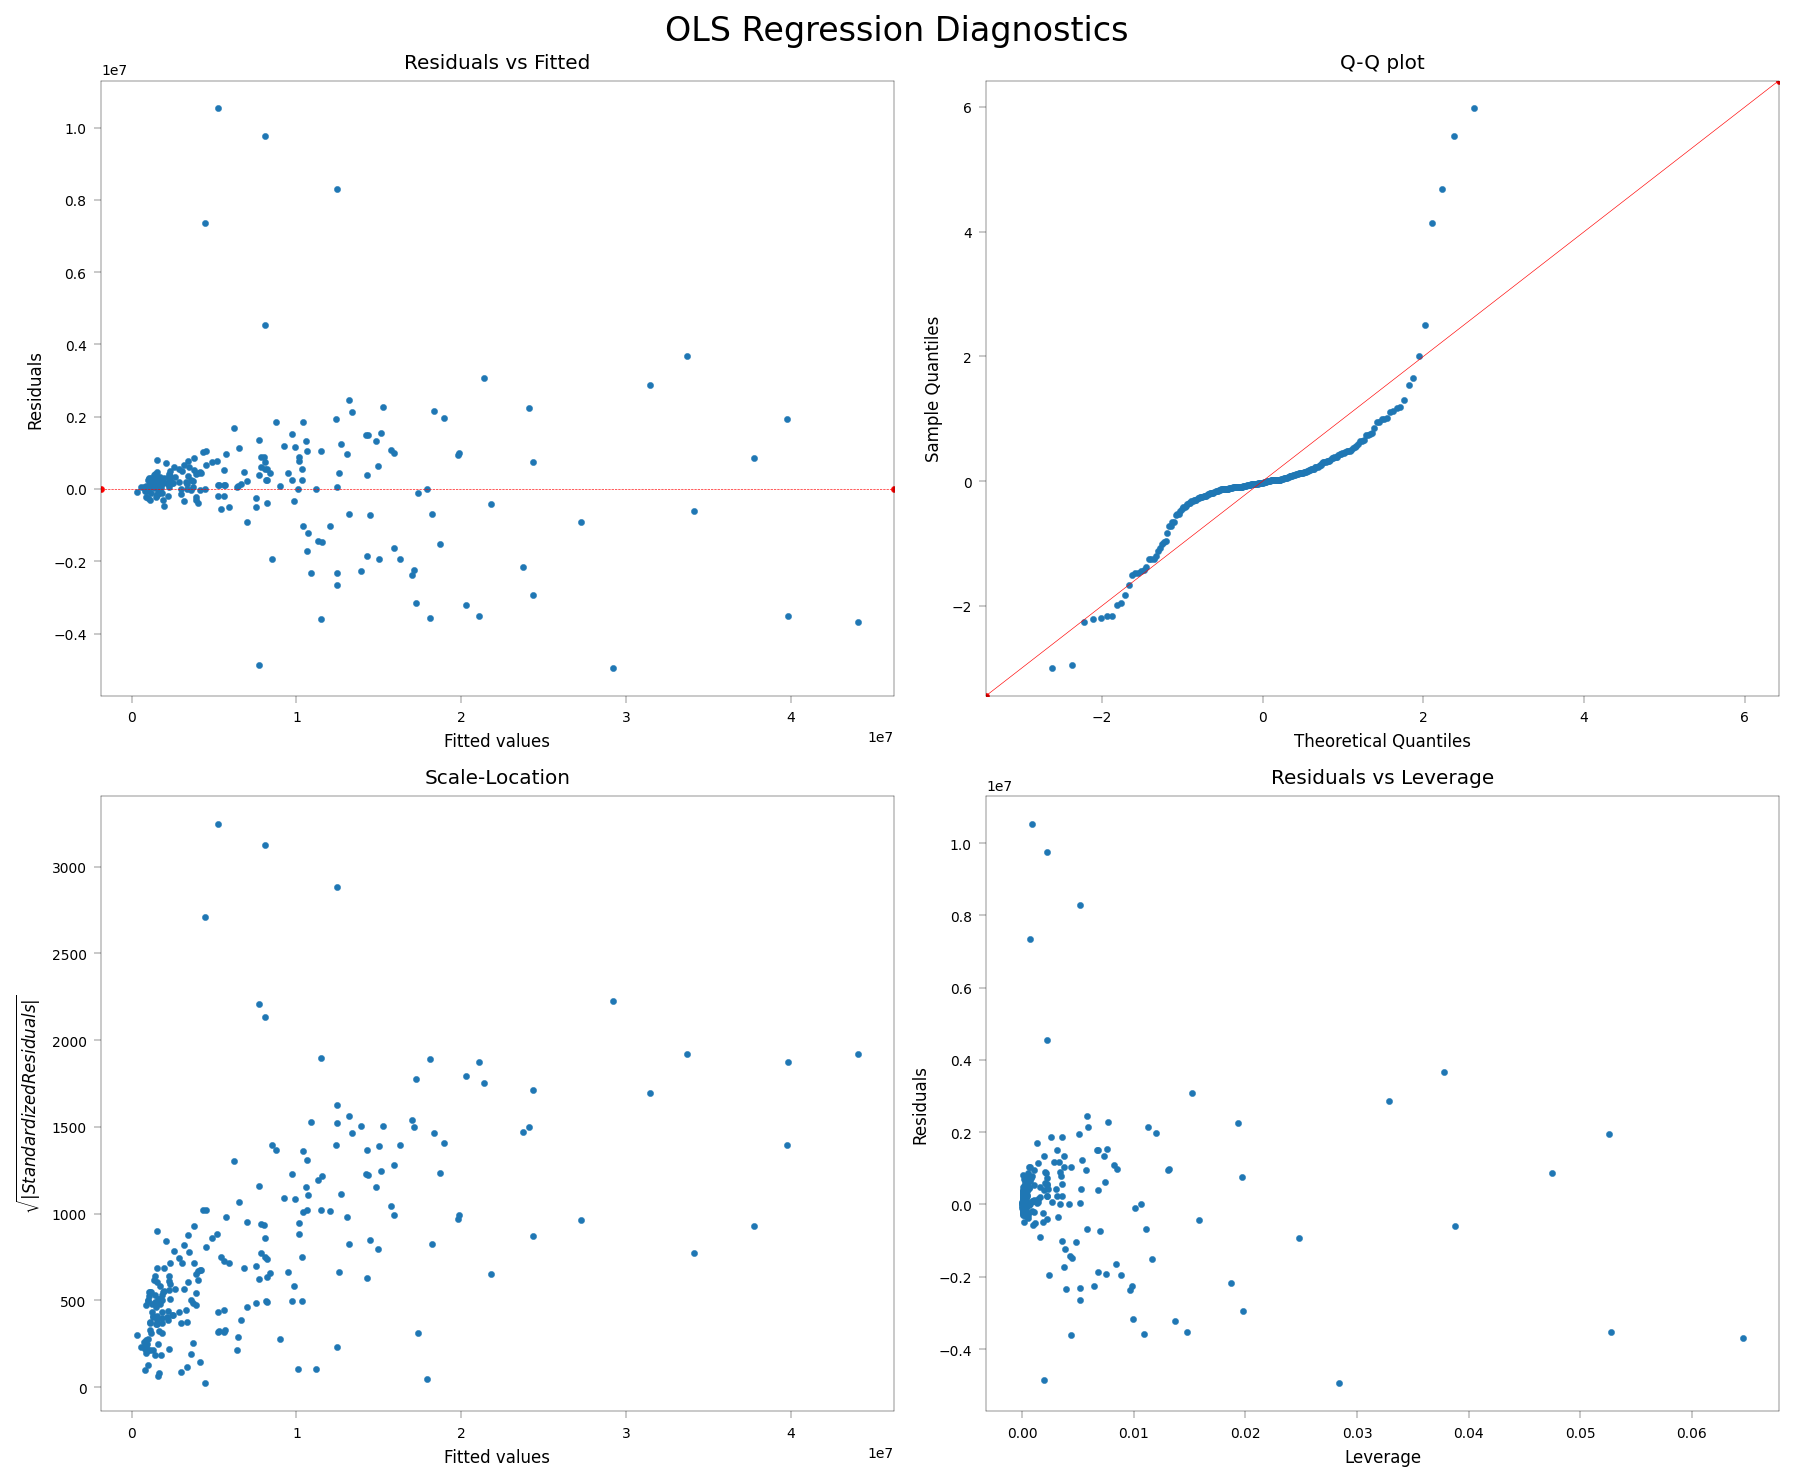

Figure saved as output\buildingstock\regression\2-2 OLS Diagnostics.svg
Figure saved as output\buildingstock\regression\2-2 OLS Diagnostics.png


In [103]:
from statsmodels.graphics.gofplots import ProbPlot
import seaborn as sns

output_dir = Path("output/buildingstock/regression/")
output_dir.mkdir(exist_ok=True)


y = df[["주거용"]]
X = df[["주민등록인구"]]

# y = df[["공업용"]]
# X = df[["주민등록인구", "사업체_수_제조업(10~34)", "종사자_수_제조업(10~34)"]]

# y = df[["교육및사회용"]]
# X = df[["주민등록인구", "재적학생수"]]

result: RegressionResults = sm.OLS(y, X).fit()


# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("OLS Regression Diagnostics", fontsize=16)

# 1. Residuals vs Fitted
axes[0, 0].scatter(result.fittedvalues, result.resid)
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted")
axes[0, 0].axhline(y=0, color="r", linestyle="--")

# 2. Q-Q plot
QQ = ProbPlot(result.resid, fit=True)
QQ.qqplot(line="45", ax=axes[0, 1])
axes[0, 1].set_title("Q-Q plot")

# # 3. Scale-Location
# axes[1, 0].scatter(result.fittedvalues, np.sqrt(np.abs(result.resid)))
# axes[1, 0].set_xlabel("Fitted values")
# axes[1, 0].set_ylabel("$\\sqrt{|Standardized Residuals|}$")
# axes[1, 0].set_title("Scale-Location")

# # 4. Residuals vs Leverage
# axes[1, 1].scatter(result.get_influence().hat_matrix_diag, result.resid)
# axes[1, 1].set_xlabel("Leverage")
# axes[1, 1].set_ylabel("Residuals")
# axes[1, 1].set_title("Residuals vs Leverage")

plt.tight_layout()
plt.show()

# Save the figure
path = output_dir / f"2-2 OLS Diagnostics.svg"
fig.savefig(path)
print(f"Figure saved as {path}")
path = output_dir / f"2-2 OLS Diagnostics.png"
fig.savefig(path)
print(f"Figure saved as {path}")

1. Residuals vs Fitted: Shows if residuals have non-linear patterns.
2. Q-Q plot: Checks if residuals are normally distributed.
3. Scale-Location: Checks for homoscedasticity (constant variance) of residuals.
4. Residuals vs Leverage: Identifies influential cases.


The second plot shows the mean residual doesn't change with the fitted values (and so is doesn't change with x
), but the spread of the residuals (and hence of the y
's about the fitted line) is increasing as the fitted values (or x
) changes. That is, the spread is not constant. Heteroscedasticity.

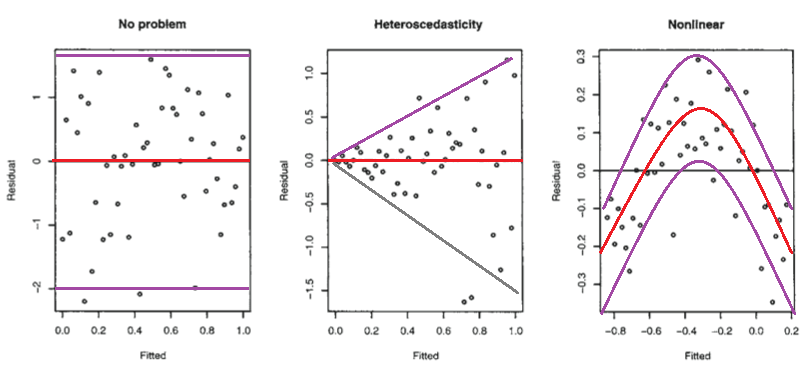

https://stats.stackexchange.com/questions/76226/interpreting-the-residuals-vs-fitted-values-plot-for-verifying-the-assumptions

OLS method(최소자승법)를 이용한 회귀분석(regression)은 세 가지의 classical assumption을 갖습니다.
이 중 세 번째는 많은 뜻을 함축하고 있는데, 그 중 하나가 오차(error-term)의 분포는 동분산(homoscedasticity)이라는 것입니다.
그렇기 때문에, 회귀분석에 앞서 자료들이 이분산성(Heteroscedasticity)을 띠는지 확인해볼 필요가 있겠습니다. 가장 간단한 방법은 회귀식의 그래프를 그려보는 것이 되겠습니다. 복잡한 방법보다도 확실히 눈으로도 확인할 수 있는 정도라면 여러 절차를 굳이 더 밟을 필요는 없을 것입니다.

어찌 되었든 이분산성(Heteroscedasticity)이 확실하게 감지되었다면 이것의 해결방법도 알아야 할 것입니다.만, 대체로 변수 설정에서부터 기인하는 경우가 많기 때문에, Data handling과정에서 보다 깔끔하게 분석할 수 있도록 처리하는 것이 좋겠습니다.

https://blog.naver.com/dhkdwnddml/220194158503


The second graph is “skewed right,” meaning that most of the data is distributed on the left side with a long “tail” of data extending out to the right.

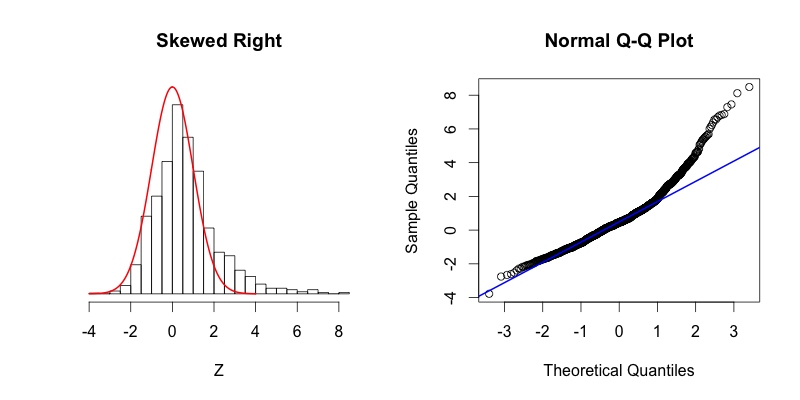

https://seankross.com/2016/02/29/A-Q-Q-Plot-Dissection-Kit.html

왜도(Skewness). 분포의 비대칭성에 대한 측도입니다. 정규 분포는 대칭이므로 왜도 값이 0입니다. 양의 왜도가 많은 분포는 오른쪽이 깁니다. 유의한 음의 왜도를 가지는 분포에는 왼쪽으로 긴 꼬리가 나타납니다. 왜도값이 표준 오차의 두 배를 넘는 것은 대칭에서 벗어난 정도를 나타냅니다.

https://www.ibm.com/docs/ko/spss-modeler/saas?topic=browser-display-statistics


적합치(예측값)의 크기에 따라 분산이 다르게 나타나는 이분산성이 존재하며, 정규분포에 비하여 평균에서 크게 벗어난 값이 드물지 않게 나타나는 오른쪽으로 치우친 분포가 나타남.
